# Palace Simulation of a Through-Silicon-Via CPW Transition

This notebook takes a coplanar waveguide (CPW) from the front of a chip to
its back through superconducting through-silicon vias (TSVs), models the
transition in 3-D with [gsim](https://gdsfactory.github.io/gsim/) and
[Palace](https://awslabs.github.io/palace/), and sets up the loop that tunes
the taper and via placement for a 50 Ω match.

The design follows the side A to side B transition of
{cite:p}`mallekFabricationSuperconductingThroughsilicon2021`: 10 × 20 µm
slot-shaped vias etched through the silicon, a CPW that tapers up to a pad
large enough to land **two signal TSVs in parallel**, and a ring of
**ground TSVs** stitching the front and back ground planes around it. A
single narrow via on its own is a large impedance discontinuity; the
parallel signal vias, the pad and the ground ring together are what keep
the reflection small.

````{only} html
```{mermaid}
flowchart TB
    A["Analytical seed<br>(conductor-backed CPW)"]
    B["TSV transition layout<br>(qpdk cells)"]
    C["FEM regions<br>(front metal, back metal, TSVs)"]
    D["Double-sided layer stack"]
    E["Mesh and driven solve"]
    F["Optimise taper and vias<br>(minimise |S11|)"]
    A --> B --> C --> D --> E --> F
    F -->|next geometry| B
```
````

::::{admonition} Required extras
:class: tip

This notebook needs the `models` extra:

```bash
uv add "qpdk[models]"
# or, from a checkout of this repository:
uv sync --extra models
# or with pip:
pip install "qpdk[models]"
```

The simulation cells additionally need the [Palace](https://awslabs.github.io/palace/)
solver itself, which is external to qpdk. The cells that invoke it are fenced
behind environment variables (see {ref}`tsv-running-palace`), so everything
up to and including the mesh runs anywhere.

See the {ref}`extras reference <notebook-extras>` for what each extra installs.
::::

```{note}
The saved Palace seed response is embedded below. The optimizer is optional
because each evaluation needs another 3-D solve.
```

In [1]:
import sys

if "google.colab" in sys.modules:
    import subprocess

    print("Running in Google Colab. Installing QPDK...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "qpdk[models] @ git+https://github.com/gdsfactory/quantum-rf-pdk.git",
    ])

In [2]:
import io
import json
import os
from pathlib import Path

import gdsfactory as gf
import klayout.db as kdb
import matplotlib.pyplot as plt
import matplotlib_inline
import numpy as np
from matplotlib import font_manager
from scipy.optimize import brentq

from qpdk import PDK, logger
from qpdk.cells import straight
from qpdk.cells.tsv import tsv, tsv_transition_double_sided
from qpdk.config import PATH
from qpdk.models.cpw import cbcpw_parameters, cpw_parameters
from qpdk.simulation import TSV_FEM_LAYERS, to_tsv_regions, tsv_stack
from qpdk.tech import LAYER, material_properties

PDK.activate()

for style in (PATH.repo / "docs" / "qpdk.mplstyle", "qpdk"):
    try:
        plt.style.use(style)
    except OSError:
        continue
    break

for font_path in (PATH.repo / "build" / "docs-fonts").glob("*"):
    if font_path.suffix.lower() in {".otf", ".ttf"}:
        font_manager.fontManager.addfont(str(font_path))

installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
plt.rcParams["font.sans-serif"] = [
    name
    for name in ("Inter", "Outfit", "DejaVu Sans", "Helvetica", "Arial")
    if name in installed_fonts
] + ["sans-serif"]
matplotlib_inline.backend_inline.set_matplotlib_formats("png")

## The via and the transition

{func}`~qpdk.cells.tsv` draws one slot-shaped via (a stadium, 10 µm wide and
20 µm long by default) with landing pads on both metal levels: ``M1`` on the
front and ``MB``, the new backside metal, on the back.
{func}`~qpdk.cells.tsv_transition_double_sided` builds the full transition
out of it. Backside geometry is drawn in the front-side frame, as if looking
through the chip, so the two faces line up in the layout view.

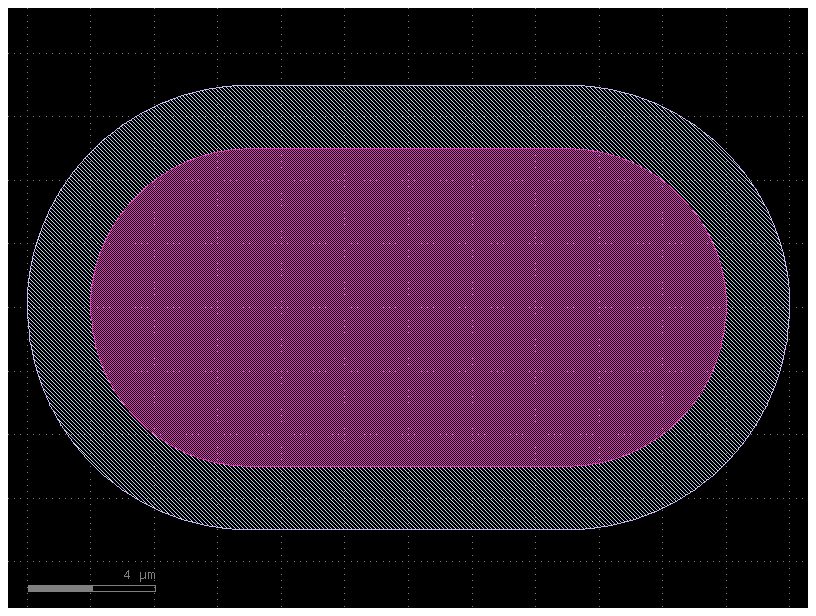

In [3]:
via = tsv()
via.plot()

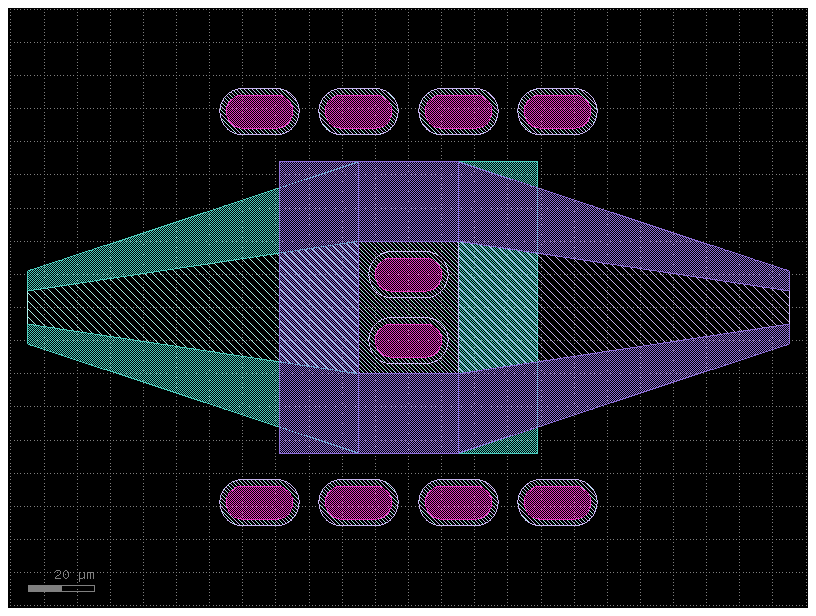

In [4]:
transition = tsv_transition_double_sided()
transition.plot()

## Conductor-backed CPW: the analytical seed

Metallising the back of the chip turns every CPW on the front into a
**conductor-backed CPW** (CBCPW): the backside ground sits one substrate
thickness $h$ below the signal line and adds a parallel-plate path that
lowers $Z_0$. {func}`~qpdk.models.cbcpw_parameters` implements the
conformal-mapping result {cite:p}`simonsCoplanarWaveguideCircuits2001`;
`cpw_parameters(..., conductor_backed=True)` switches the qpdk CPW models to
it. For the standard 10/6 µm line on 200 µm silicon the correction is small,
but it grows with the line's lateral size, so it matters for the wide pad
the TSVs land on.

The seed geometry picks, for each pad width, the gap that gives 50 Ω as a
CBCPW on the 200 µm substrate of the paper.

findfont: Failed to find font weight bold, now using 400.


/Users/nikosavola/.worktrees/quantum-rf-pdk/palace-new/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 937 (\N{GREEK CAPITAL LETTER OMEGA}) missing from font(s) Outfit.
  fig.canvas.print_figure(bytes_io, **kw)


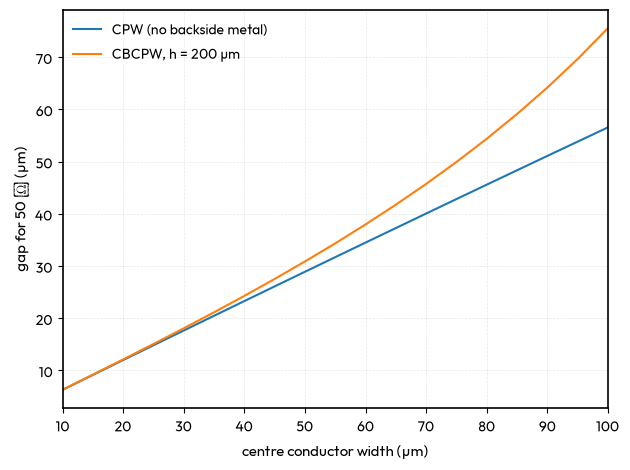

2026-09-29 02:33:36.042 | INFO     | __main__:<module>:37 - lead 10/6 µm: 49.27 Ω backed, 49.31 Ω unbacked


2026-09-29 02:33:36.042 | INFO     | __main__:<module>:41 - seed pad: width 40 µm, gap 24.29 µm


In [5]:
SUBSTRATE_THICKNESS = 200.0  # µm, the TSV depth
METAL_THICKNESS = 0.2  # µm
Z_TARGET = 50.0  # Ω
EP_R = material_properties["Si"]["relative_permittivity"]


def cbcpw_z0(width: float, gap: float, h: float = SUBSTRATE_THICKNESS) -> float:
    """Return the conductor-backed CPW impedance for µm dimensions."""
    _, z0 = cbcpw_parameters(
        width * 1e-6, gap * 1e-6, h * 1e-6, METAL_THICKNESS * 1e-6, EP_R
    )
    return float(z0)


def gap_for_z0(width: float, z0: float = Z_TARGET) -> float:
    """Return the CBCPW gap in µm that gives ``z0`` for a given width."""
    return brentq(lambda gap: cbcpw_z0(width, gap) - z0, 0.5, 20 * width)


widths = np.linspace(10.0, 100.0, 19)
gaps_backed = np.array([gap_for_z0(w) for w in widths])
gaps_free = np.array([
    brentq(lambda g, w=w: float(cpw_parameters(w, g)[1]) - Z_TARGET, 0.5, 20 * w)
    for w in widths
])

_, ax = plt.subplots()
ax.plot(widths, gaps_free, label="CPW (no backside metal)")
ax.plot(widths, gaps_backed, label=f"CBCPW, h = {SUBSTRATE_THICKNESS:.0f} µm")
ax.set_xlabel("centre conductor width (µm)")
ax.set_ylabel("gap for 50 Ω (µm)")
ax.legend()
plt.show()

seed_pad_width = 40.0
seed_pad_gap = gap_for_z0(seed_pad_width)
logger.info(
    f"lead 10/6 µm: {cbcpw_z0(10.0, 6.0):.2f} Ω backed,"
    f" {float(cpw_parameters(10.0, 6.0)[1]):.2f} Ω unbacked"
)
logger.info(f"seed pad: width {seed_pad_width:.0f} µm, gap {seed_pad_gap:.2f} µm")

The two curves separate as the line widens: at 100 µm the backside metal
calls for a visibly wider gap. The analytic model says nothing about the
vias themselves, which is what the 3-D model is for.

## Simulation layout

The simulation wraps the transition in three things:

- **Straight CPW leads** on both faces. Palace's lumped CPW port must sit
  on a uniform section: a port rectangle placed on the taper is no longer
  rectangular and fails gsim's port check.
- **Etch stubs** past each port, which end the signal line so the port
  drives it as an open-ended feed, as in
  {doc}`palace_eigenmode_qubit_resonator`.
- A ``SIM_AREA`` rectangle 100 µm around the device, bounding the domain on
  both faces. The ground planes run to its edge.

`sim_component` takes the transition parameters, so the optimiser below
rebuilds the same wrapper around each candidate.

2026-09-29 02:33:36.058 | INFO     | __main__:<module>:29 - simulation area: (-255,-166.29;255,166.29)


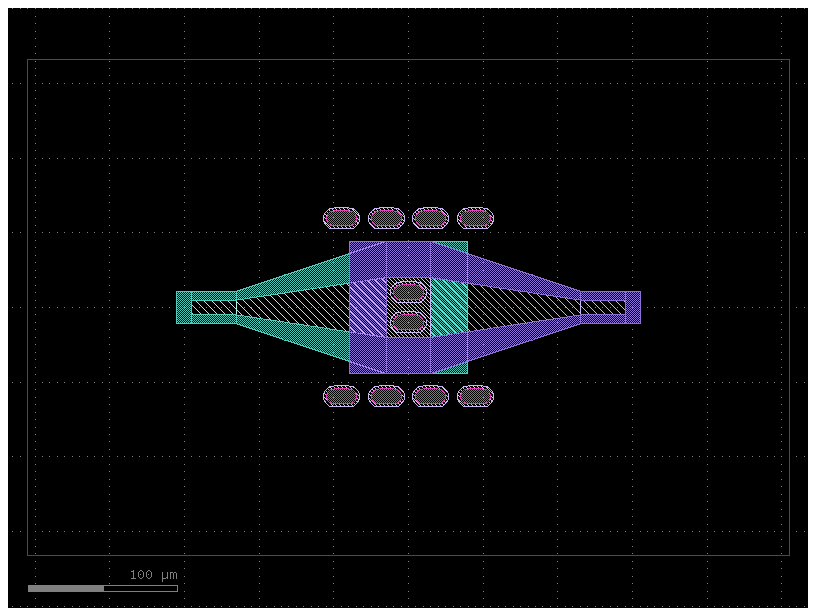

In [6]:
LEAD_LENGTH = 30.0  # µm
STUB_LENGTH = 10.0  # µm


@gf.cell
def sim_component(**params: float) -> gf.Component:
    """TSV transition with CPW leads, etch stubs and a simulation area."""
    c = gf.Component()
    dut = c << tsv_transition_double_sided(**params)
    front = c << straight(length=LEAD_LENGTH, cross_section="cpw")
    front.connect("o2", dut.ports["o1"])
    back = c << straight(length=LEAD_LENGTH, cross_section="cpw_backside")
    back.connect("o1", dut.ports["o2"])
    c.add_port("o1", port=front.ports["o1"])
    c.add_port("o2", port=back.ports["o2"])
    for port, etch, sign in (
        (c.ports["o1"], LAYER.M1_ETCH, -1),
        (c.ports["o2"], LAYER.MB_ETCH, 1),
    ):
        half = port.width / 2 + 6.0  # signal plus the 6 µm gaps
        x0, x1 = sorted((port.x, port.x + sign * STUB_LENGTH))
        c.kdb_cell.shapes(etch).insert(kdb.DBox(x0, -half, x1, half))
    c.kdb_cell.shapes(LAYER.SIM_AREA).insert(c.bbox().enlarged(100, 100))
    return c


seed_params = {"pad_width": seed_pad_width, "pad_gap": round(seed_pad_gap, 2)}
layout_c = sim_component(**seed_params)
logger.info(f"simulation area: {layout_c.bbox()}")
layout_c.plot()

## From etch layers to FEM regions

{func}`~qpdk.simulation.to_tsv_regions` applies the subtractive convention
on both metal levels (conductor is ``SIM_AREA - ETCH + DRAW``, matching
{data}`~qpdk.tech.LAYER_STACK_BACKSIDE`) and copies the TSVs to their own
region. The checks below are the circuit topology made visible: each face
splits into a ground plane and the signal line, and every via lands on
metal on **both** faces, so the ground vias really tie the two ground
planes together and the signal vias really carry the line through.

In [7]:
regions = to_tsv_regions(layout_c)
rlayout = regions.kdb_cell.layout()


def region(name: str) -> kdb.Region:
    """Return the merged region of one TSV FEM layer."""
    return kdb.Region(
        regions.kdb_cell.begin_shapes_rec(rlayout.layer(*TSV_FEM_LAYERS[name]))
    ).merged()


for name, (lnum, ldt) in TSV_FEM_LAYERS.items():
    logger.info(
        f"{name:>14} ({lnum},{ldt}): {len(region(name))} polygons,"
        f" {region(name).area() * 1e-6:.0f} µm²"
    )
m1, mb, vias = region("M1"), region("MB"), region("TSV")
assert len(m1) == 2, "front metal should be ground plane + signal line"
assert len(mb) == 2, "back metal should be ground plane + signal line"
assert (vias - m1).is_empty(), "a TSV does not land on front-side metal"
assert (vias - mb).is_empty(), "a TSV does not land on backside metal"

2026-09-29 02:33:36.139 | INFO     | __main__:<module>:13 -  VACUUM_BOTTOM (108,0): 1 polygons, 169616 µm²


2026-09-29 02:33:36.139 | INFO     | __main__:<module>:13 -             MB (109,0): 2 polygons, 162398 µm²


2026-09-29 02:33:36.139 | INFO     | __main__:<module>:13 -      SUBSTRATE (110,0): 1 polygons, 169616 µm²


2026-09-29 02:33:36.140 | INFO     | __main__:<module>:13 -            TSV (111,0): 10 polygons, 1784 µm²


2026-09-29 02:33:36.140 | INFO     | __main__:<module>:13 -             M1 (112,0): 2 polygons, 162398 µm²


2026-09-29 02:33:36.140 | INFO     | __main__:<module>:13 -         VACUUM (113,0): 1 polygons, 169616 µm²


## Layer stack and driven setup

{func}`~qpdk.simulation.tsv_stack` puts the front metal at $z=0$ and the
backside metal at $z=-h$, both as zero-thickness perfect conductors, with
air above and below the chip. The TSVs are "via" layers spanning the full
substrate. They need a material with a conductivity, without which gsim
demotes each via to a 2-D sheet at its base and the two faces no longer
connect. The model fills the vias solid, while the paper's vias are TiN
liners around a hollow core; at microwave frequencies the current flows on
the via wall either way, so the solid via is a good approximation of the
field problem.

One CPW port sits on each face. The driven solve sweeps 1 to 12 GHz with
Palace's adaptive frequency sampling.

In [8]:
from gsim.palace import DrivenSim

from qpdk.simulation.palace_run import verify_port_connectivity

F_MIN, F_MAX = 1e9, 12e9  # Hz


def build_simulation(
    params: dict[str, float], sim_dir: Path, *, preset: str = "coarse"
) -> DrivenSim:
    """Build, mesh and write a driven simulation of one transition geometry.

    Returns:
        The configured simulation, ready for a Palace solve in ``sim_dir``.
    """
    sim = DrivenSim()
    sim.set_geometry(to_tsv_regions(sim_component(**params)))
    sim.set_stack(
        tsv_stack(substrate_thickness=SUBSTRATE_THICKNESS, vacuum_thickness=300.0)
    )
    sim.set_numerical(order=1, solver_type="MUMPS")
    sim.add_cpw_port("o1", layer="M1", s_width=10.0, gap_width=6.0, length=5.0)
    sim.add_cpw_port("o2", layer="MB", s_width=10.0, gap_width=6.0, length=5.0)
    sim.set_driven(
        fmin=F_MIN,
        fmax=F_MAX,
        num_points=17,
        adaptive_tol=3e-3,
        reference_impedance=Z_TARGET,
    )
    sim.set_output_dir(sim_dir)
    sim.mesh(preset=preset, refined_mesh_size=2.0, auto_size=False, verbose=False)
    sim.write_config()
    config_path = sim_dir / "config.json"
    config = json.loads(config_path.read_text())
    config["Solver"]["Linear"]["MaxIts"] = 10
    config["Solver"]["Linear"]["ColumnOrdering"] = "ParMETIS"
    config_path.write_text(json.dumps(config, indent=2) + "\n")
    verify_port_connectivity(sim_dir)
    return sim


SIM_DIR = Path("./sim_palace_tsv")
sim = build_simulation(seed_params, SIM_DIR)

pyvirtualdisplay not available; continuing without Xvfb


Info    : Reading 'sim_palace_tsv/palace.msh'...
Info    : 113092 nodes
Info    : 746979 elements


Info    : Done reading 'sim_palace_tsv/palace.msh'


Info    : Reading 'sim_palace_tsv/palace.msh'...
Info    : 113092 nodes
Info    : 746979 elements


Info    : Done reading 'sim_palace_tsv/palace.msh'
Info    : Reading 'sim_palace_tsv/palace.msh'...
Info    : 113092 nodes


Info    : 746979 elements


Info    : Done reading 'sim_palace_tsv/palace.msh'
Info    : Reading 'sim_palace_tsv/palace.msh'...
Info    : 113092 nodes
Info    : 746979 elements


Info    : Done reading 'sim_palace_tsv/palace.msh'
Info    : Reading 'sim_palace_tsv/palace.msh'...
Info    : 113092 nodes
Info    : 746979 elements


Info    : Done reading 'sim_palace_tsv/palace.msh'


### Mesh checks

The volumes should span the chip and the air on both sides, and the two PEC
sheets should sit at $z=0$ and $z=-h$. The port check above has already
confirmed that both CPW ports share mesh nodes with metal.

In [9]:
import gmsh

gmsh.initialize()
gmsh.open(str(SIM_DIR / "palace.msh"))
for dim, tag in gmsh.model.getPhysicalGroups(3):
    bbox = gmsh.model.getBoundingBox(
        3, gmsh.model.getEntitiesForPhysicalGroup(3, tag)[0]
    )
    logger.info(
        f"volume {gmsh.model.getPhysicalName(dim, tag):>14}: z [{bbox[2]:.0f}, {bbox[5]:.0f}] µm"
    )
pec_z = {}
for dim, tag in gmsh.model.getPhysicalGroups(2):
    name = gmsh.model.getPhysicalName(dim, tag)
    if name.endswith("_pec"):
        bbox = gmsh.model.getBoundingBox(
            2, gmsh.model.getEntitiesForPhysicalGroup(2, tag)[0]
        )
        pec_z[name] = round(bbox[2], 6) + 0.0
        logger.info(f"surface {name:>13}: z = {bbox[2]:.0f} µm")
gmsh.finalize()
assert pec_z == {"M1_pec": 0.0, "MB_pec": -SUBSTRATE_THICKNESS}, pec_z

Info    : Reading 'sim_palace_tsv/palace.msh'...
Info    : 113092 nodes
Info    : 746979 elements


2026-09-29 02:35:05.183 | INFO     | __main__:<module>:9 - volume  VACUUM_BOTTOM: z [-500, -200] µm


2026-09-29 02:35:05.187 | INFO     | __main__:<module>:9 - volume      SUBSTRATE: z [-200, 0] µm


2026-09-29 02:35:05.187 | INFO     | __main__:<module>:9 - volume            TSV: z [-200, 0] µm


2026-09-29 02:35:05.188 | INFO     | __main__:<module>:9 - volume         VACUUM: z [-0, 300] µm


2026-09-29 02:35:05.188 | INFO     | __main__:<module>:20 - surface        MB_pec: z = -200 µm


2026-09-29 02:35:05.188 | INFO     | __main__:<module>:20 - surface        M1_pec: z = -0 µm


Info    : Done reading 'sim_palace_tsv/palace.msh'


(tsv-running-palace)=
## Running Palace

The solve needs the Palace binary: set ``QPDK_RUN_TSV_SOLVE=1`` and either
put ``palace`` on ``PATH`` or point ``QPDK_PALACE_SIF`` at an Apptainer
image. {func}`~qpdk.simulation.palace_run.solve` launches it with
``QPDK_SOLVER_CORES`` MPI ranks, and gsim reads the S-parameters back.

From the two-port S-matrix, $|S_{11}|$ is the figure of merit and the
reflection also gives the input impedance the transition presents to the
front-side 50 Ω line,

```{math}
Z_\text{in} = Z_0 \frac{1 + S_{11}}{1 - S_{11}} .
```

In [10]:
from gsim.palace import load_sparams

from qpdk.simulation.palace_run import solve

RUN_SOLVE = os.environ.get("QPDK_RUN_TSV_SOLVE") == "1"
RUN_OPTIMIZATION = os.environ.get("QPDK_RUN_TSV_OPTIMIZATION") == "1"
RANKS = int(os.environ.get("QPDK_SOLVER_CORES") or 8)
BAND = (4.0, 8.0)  # GHz, the units of Palace's port-S.csv


def plot_sparams(f: np.ndarray, s11: np.ndarray, s21: np.ndarray) -> None:
    """Plot the two-port response with frequency in GHz."""
    z_in = Z_TARGET * (1 + s11) / (1 - s11)
    fig, (ax_s, ax_z) = plt.subplots(1, 2, figsize=(10, 4))
    ax_s.plot(f, 20 * np.log10(np.abs(s11)), label="$|S_{11}|$")
    ax_s.plot(f, 20 * np.log10(np.abs(s21)), label="$|S_{21}|$")
    ax_s.axvspan(*BAND, alpha=0.1)
    ax_s.set(xlabel="frequency (GHz)", ylabel="dB")
    ax_s.legend()
    ax_z.plot(f, z_in.real, label=r"Re $Z_\text{in}$")
    ax_z.plot(f, z_in.imag, label=r"Im $Z_\text{in}$")
    ax_z.axhline(Z_TARGET, color="k", lw=0.5)
    ax_z.set(xlabel="frequency (GHz)", ylabel="Ω")
    ax_z.legend()
    plt.show()
    plt.close(fig)

### Saved seed response

Palace solved the seed geometry with first-order elements on a mesh refined
to 2 µm near the metal, using 17 frequency samples and a 0.3% adaptive
tolerance. The table is the first excitation of its `port-S.csv`. This is a
seed result; the optimization loop below has not been run.

/Users/nikosavola/.worktrees/quantum-rf-pdk/palace-new/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 937 (\N{GREEK CAPITAL LETTER OMEGA}) missing from font(s) Outfit.
  fig.canvas.print_figure(bytes_io, **kw)


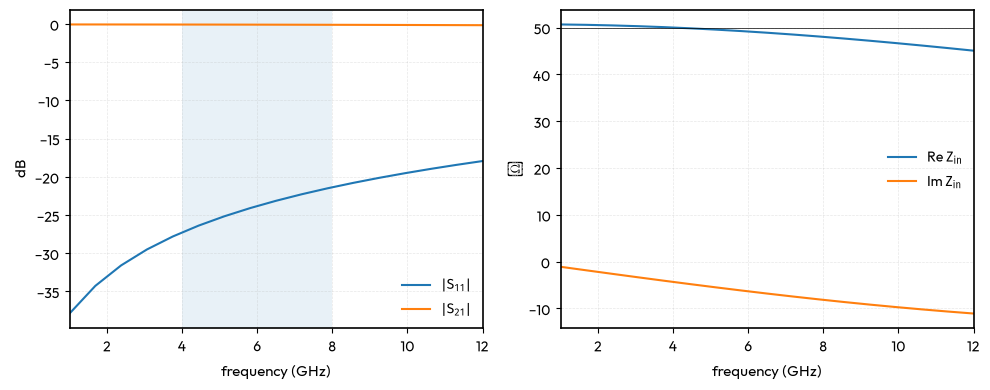

2026-09-29 02:35:05.282 | INFO     | __main__:<module>:41 - worst sampled |S11| from 4 to 8 GHz: -21.5 dB


In [11]:
SAVED_PORT_S_CSV = """\
frequency_ghz,s11_db,s11_deg,s21_db,s21_deg
1,-37.8812446,-58.726799,-0.0612678554,-1.83330649
1.6875,-34.2632696,-71.8243797,-0.0626489377,-3.09330909
2.375,-31.5822063,-78.7315897,-0.0647258694,-4.35271768
3.0625,-29.4979027,-83.208716,-0.0674869642,-5.61131342
3.75,-27.8042377,-86.5168997,-0.0709181266,-6.86889532
4.4375,-26.3820444,-89.1800377,-0.0750036226,-8.12528068
5.125,-25.1583817,-91.4517417,-0.0797267257,-9.38030403
5.8125,-24.0858963,-93.4689499,-0.0850701892,-10.6338154
6.5,-23.1322805,-95.3118228,-0.0910165542,-11.8856783
7.1875,-22.2745762,-97.0302761,-0.0975483307,-13.1357676
7.875,-21.4959133,-98.6569394,-0.104648094,-14.3839683
8.5625,-20.7835459,-100.213992,-0.112298535,-15.630174
9.25,-20.1276157,-101.716999,-0.120482477,-16.8742858
9.9375,-19.520344,-103.177176,-0.129182891,-18.1162116
10.625,-18.9554871,-104.602788,-0.138382892,-19.3558654
11.3125,-18.4279575,-106.000038,-0.148065739,-20.5931665
12,-17.9335551,-107.373659,-0.158214829,-21.8280396
"""


def phasor(db: np.ndarray, deg: np.ndarray) -> np.ndarray:
    """Convert a Palace dB and degree pair to complex S-parameters."""
    return 10 ** (db / 20) * np.exp(1j * np.deg2rad(deg))


if RUN_SOLVE:
    solve(SIM_DIR, ranks=RANKS)
    sp = load_sparams(SIM_DIR)
    f = np.asarray(sp.freq)
    s11 = np.asarray(sp["o1", "o1"].complex)
    s21 = np.asarray(sp["o2", "o1"].complex)
else:
    saved = np.loadtxt(io.StringIO(SAVED_PORT_S_CSV), delimiter=",", skiprows=1)
    f = saved[:, 0]
    s11 = phasor(saved[:, 1], saved[:, 2])
    s21 = phasor(saved[:, 3], saved[:, 4])
plot_sparams(f, s11, s21)
in_band = (f >= BAND[0]) & (f <= BAND[1])
logger.info(
    f"worst sampled |S11| from {BAND[0]:g} to {BAND[1]:g} GHz: "
    f"{np.max(20 * np.log10(np.abs(s11[in_band]))):.1f} dB"
)

## Optimising the transition for 50 Ω

The paper tunes the transition shape to minimise reflections. The loop
below does the same with Palace in the loop: each evaluation builds a
geometry, meshes it, solves it, and scores it by the worst in-band
reflection,

```{math}
J = \max_{f \in [4, 8]\,\text{GHz}} 20 \log_{10} |S_{11}(f)| .
```

The free parameters are the ones the analytic model cannot fix: the taper
length, the pad width, the spacing of the two signal vias and the distance
of the ground-via ring from the pad edge. The pad gap is not a free
parameter: it follows the pad width through the CBCPW seed, so the pad
stays a 50 Ω line and the optimiser spends its evaluations on the vias.
Nelder–Mead from the seed needs no gradients and tolerates the small mesh
noise between neighbouring geometries; each evaluation is one independent
Palace run, so the same objective drops into the Optuna/Slurm driver of
{doc}`palace_batched_qubit_optimization` for a wider search.

In [12]:
from scipy.optimize import minimize

PARAMETERS = {
    # name: (seed, lower bound, upper bound), µm
    "taper_length": (100.0, 30.0, 250.0),
    "pad_width": (seed_pad_width, 30.0, 80.0),
    "signal_via_pitch": (20.0, 14.0, 34.0),
    "ground_via_distance": (15.0, 8.0, 60.0),
}


def geometry(x: np.ndarray) -> dict[str, float]:
    """Map an optimiser vector to transition parameters, 50 Ω pad included."""
    params = {name: round(float(v), 2) for name, v in zip(PARAMETERS, x, strict=True)}
    params["taper_length_backside"] = params["taper_length"]
    params["pad_gap"] = round(gap_for_z0(params["pad_width"]), 2)
    return params


def objective(x: np.ndarray, run_root: Path = Path("./sim_palace_tsv_opt")) -> float:
    """Return the worst in-band |S11| in dB for one geometry."""
    params = geometry(x)
    sim_dir = run_root / "_".join(f"{v:g}" for v in params.values())
    try:
        build_simulation(params, sim_dir)
    except ValueError as err:  # geometry the cell rejects, e.g. vias off the pad
        logger.warning(f"{params}: {err}")
        return 0.0
    solve(sim_dir, ranks=RANKS)
    sp = load_sparams(sim_dir)
    f = np.asarray(sp.freq)
    in_band = (f >= BAND[0]) & (f <= BAND[1])
    cost = float(np.max(np.asarray(sp["o1", "o1"].db)[in_band]))
    logger.info(f"{params} -> max |S11| = {cost:.1f} dB")
    return cost


x0 = np.array([seed for seed, _, _ in PARAMETERS.values()])
bounds = [(lo, hi) for _, lo, hi in PARAMETERS.values()]
logger.info(f"seed geometry: {geometry(x0)}")

if RUN_OPTIMIZATION:
    result = minimize(
        objective,
        x0,
        method="Nelder-Mead",
        bounds=bounds,
        options={"maxfev": 40, "xatol": 1.0, "fatol": 0.5},
    )
    best = geometry(result.x)
    logger.info(f"best geometry: {best}, max |S11| = {result.fun:.1f} dB")
    best_dir = Path("./sim_palace_tsv_best")
    build_simulation(best, best_dir, preset="default")
    solve(best_dir, ranks=RANKS)
    best_sp = load_sparams(best_dir)
    plot_sparams(
        np.asarray(best_sp.freq),
        np.asarray(best_sp["o1", "o1"].complex),
        np.asarray(best_sp["o2", "o1"].complex),
    )
else:
    logger.info("QPDK_RUN_TSV_OPTIMIZATION is not set; skipping the optimisation.")

2026-09-29 02:35:05.287 | INFO     | __main__:<module>:40 - seed geometry: {'taper_length': 100.0, 'pad_width': 40.0, 'signal_via_pitch': 20.0, 'ground_via_distance': 15.0, 'taper_length_backside': 100.0, 'pad_gap': 24.29}


2026-09-29 02:35:05.287 | INFO     | __main__:<module>:62 - QPDK_RUN_TSV_OPTIMIZATION is not set; skipping the optimisation.


A rejected geometry scores 0 dB, a total reflection, so the optimiser
backs away from it instead of stopping. The best geometry is re-solved on
the finer ``default`` mesh preset before it is trusted: a match found on a
coarse mesh can partly be a mesh artefact.

## Summary

- {func}`~qpdk.cells.tsv` and {func}`~qpdk.cells.tsv_transition_double_sided`
  draw the slot vias and the two-signal-via transition of
  {cite:p}`mallekFabricationSuperconductingThroughsilicon2021` on the new
  ``MB`` backside metal.
- The backside metal makes the CPWs conductor-backed;
  {func}`~qpdk.models.cbcpw_parameters` and the ``conductor_backed`` switch
  of the CPW models account for it and seed the pad geometry at 50 Ω.
- {func}`~qpdk.simulation.to_tsv_regions` and
  {func}`~qpdk.simulation.tsv_stack` produce a meshed, port-checked Palace
  model of the transition, and the objective above closes the loop on
  $|S_{11}|$.

Natural next steps: model the TSV liner as a thin conductive shell rather
than a solid via, and add the kinetic inductance of the thin TiN lining,
which a PEC-and-conductor model leaves out.

## References

```{bibliography}
:filter: docname in docnames
```